In [1]:
# Import the required libraries

import pandas as pd
import numpy as np
import joblib
import matplotlib.pyplot as plt
from pathlib import Path

In [2]:
# Set the project folders

current_path = Path.cwd()

if current_path.name == "notebooks":
    project_root = current_path.parent
else:
    project_root = current_path

data_path = project_root / "data" / "processed"
models_path = project_root / "models"

models_path.mkdir(parents=True, exist_ok=True)

print("Project folder:", project_root)

Project folder: /mnt/data/model_explanation_project


In [3]:
# Load the model dataset, membership data and trained model

model_data = pd.read_csv(data_path / "churn_model_dataset.csv")
memberships = pd.read_csv(data_path / "memberships.csv")
churn_model = joblib.load(models_path / "churn_model.joblib")

print("Model dataset:", model_data.shape)
print("Membership data:", memberships.shape)
print("Saved model loaded")

Model dataset: (35193, 36)
Membership data: (55000, 13)
Saved model loaded


In [4]:
# Prepare the customer features

leakage_columns = [
    "customer_id",
    "membership_status",
    "cancellation_date",
    "cancellation_reason",
    "membership_end_date",
    "churn_flag",
    "churn_next_30_days"
]

model_columns_to_remove = [
    column for column in leakage_columns
    if column in model_data.columns
]

X = model_data.drop(columns=model_columns_to_remove)

model_data["churn_probability"] = churn_model.predict_proba(X)[:, 1]

print("Customers scored:", len(model_data))
print("Average churn probability:",
      round(model_data["churn_probability"].mean(), 4))

Customers scored: 35193
Average churn probability: 0.2567


In [5]:
# Calculate feature importance

preprocessor = churn_model.named_steps["preprocessor"]
trained_model = churn_model.named_steps["model"]

numeric_columns = preprocessor.transformers_[0][2]
categorical_columns = preprocessor.transformers_[1][2]

encoder = (
    preprocessor
    .named_transformers_["categorical"]
    .named_steps["one_hot_encode"]
)

model_importance = trained_model.feature_importances_

feature_rows = []
position = 0

for column in numeric_columns:
    feature_rows.append({
        "feature": column,
        "importance": model_importance[position]
    })
    position += 1

for column, categories in zip(
    categorical_columns,
    encoder.categories_
):
    category_count = len(categories)

    feature_rows.append({
        "feature": column,
        "importance": model_importance[
            position:position + category_count
        ].sum()
    })

    position += category_count

feature_importance = pd.DataFrame(feature_rows)

feature_importance = feature_importance.sort_values(
    "importance",
    ascending=False
).reset_index(drop=True)

feature_importance["rank"] = (
    feature_importance.index + 1
)

feature_importance["importance_percent"] = (
    feature_importance["importance"] * 100
).round(4)

feature_importance = feature_importance[
    ["rank", "feature", "importance", "importance_percent"]
]

feature_importance.to_csv(
    models_path / "feature_importance.csv",
    index=False
)

feature_importance.head(15)

,rank,feature,importance,importance_percent
0,1,auto_renew_enabled,0.676545,67.6545
1,2,days_since_last_activity,0.119718,11.9718
2,3,tenure_months,0.064106,6.4106
3,4,total_active_days,0.040904,4.0904
4,5,days_since_last_video_activity,0.017963,1.7963
5,6,average_satisfaction_score,0.014269,1.4269
6,7,days_since_last_order,0.013456,1.3456
7,8,average_completion_rate,0.011087,1.1087
8,9,shipping_fee_saved,0.008561,0.8561
9,10,orders_last_30_days,0.008073,0.8073


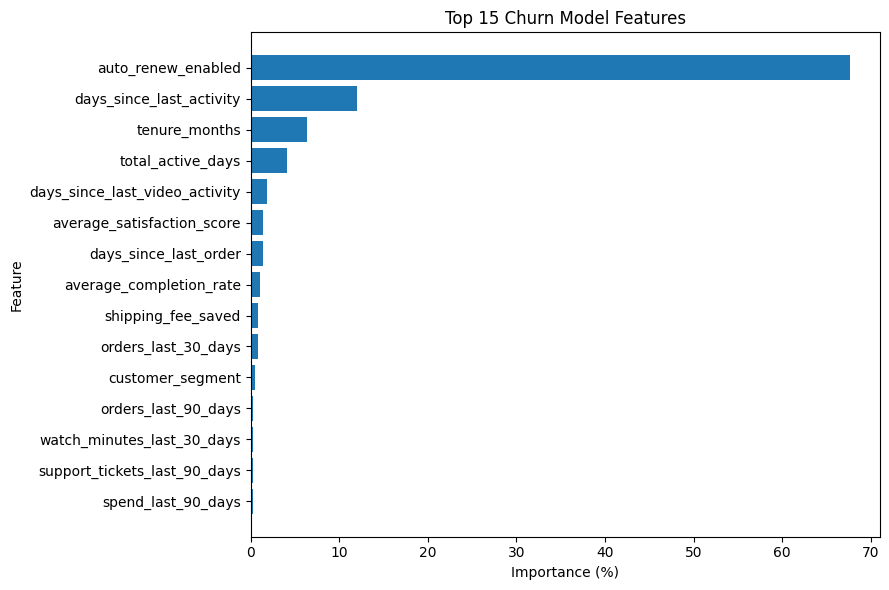

In [6]:
# Plot the most important features

top_features = feature_importance.head(15).sort_values(
    "importance_percent"
)

plt.figure(figsize=(9, 6))
plt.barh(
    top_features["feature"],
    top_features["importance_percent"]
)
plt.xlabel("Importance (%)")
plt.ylabel("Feature")
plt.title("Top 15 Churn Model Features")
plt.tight_layout()
plt.show()

In [7]:
# Create the customer risk groups

model_data["risk_level"] = pd.cut(
    model_data["churn_probability"],
    bins=[-np.inf, 0.30, 0.70, np.inf],
    labels=["Low Risk", "Medium Risk", "High Risk"],
    right=False
)

model_data["risk_level"].value_counts()

risk_level
Low Risk       25070
Medium Risk     6323
High Risk       3800
Name: count, dtype: int64

In [8]:
# Find the membership active on the scoring date

scoring_date = pd.Timestamp("2026-05-31")

date_columns = [
    "membership_start_date",
    "renewal_date",
    "membership_end_date",
    "cancellation_date"
]

for column in date_columns:
    memberships[column] = pd.to_datetime(
        memberships[column],
        errors="coerce"
    )

active_memberships = memberships[
    (memberships["membership_start_date"] <= scoring_date)
    & (
        memberships["membership_end_date"].isna()
        | (memberships["membership_end_date"] >= scoring_date)
    )
    & (
        memberships["cancellation_date"].isna()
        | (memberships["cancellation_date"] > scoring_date)
    )
].copy()

active_memberships = active_memberships.sort_values(
    [
        "customer_id",
        "membership_start_date",
        "renewal_date",
        "membership_id"
    ]
)

active_memberships = active_memberships.drop_duplicates(
    "customer_id",
    keep="last"
)

membership_revenue = active_memberships[
    [
        "customer_id",
        "membership_fee",
        "billing_cycle"
    ]
].copy()

print("Active memberships found:",
      len(active_memberships))

Active memberships found: 39218


In [9]:
# Estimate monthly membership revenue at risk

membership_revenue["monthly_membership_revenue"] = np.where(
    membership_revenue["billing_cycle"] == "Annual",
    membership_revenue["membership_fee"] / 12,
    membership_revenue["membership_fee"]
)

model_data = model_data.merge(
    membership_revenue[
        ["customer_id", "monthly_membership_revenue"]
    ],
    on="customer_id",
    how="left"
)

model_data["monthly_membership_revenue"] = (
    model_data["monthly_membership_revenue"]
    .fillna(0)
)

model_data["membership_revenue_at_risk"] = (
    model_data["monthly_membership_revenue"]
    * model_data["churn_probability"]
).round(2)

model_data[
    [
        "customer_id",
        "churn_probability",
        "monthly_membership_revenue",
        "membership_revenue_at_risk"
    ]
].head()

,customer_id,churn_probability,monthly_membership_revenue,membership_revenue_at_risk
0,CUST025026,0.889802,1.349167,1.20
1,CUST020499,0.489819,11.583333,5.67
2,CUST001658,0.051151,1.199167,0.06
3,CUST044227,0.180921,4.190000,0.76
4,CUST001102,0.245940,1.499167,0.37


In [10]:
# Assign one main risk driver and retention action

def assign_action(row):
    if (
        row["payment_failures_last_90_days"] > 0
        or row["payment_retries_last_90_days"] >= 2
        or row["last_payment_failed"] == 1
    ):
        return (
            "Payment failure",
            "Send payment-update reminder"
        )

    if row["auto_renew_enabled"] == "No":
        return (
            "Auto-renew disabled",
            "Send renewal reminder"
        )

    if (
        row["support_tickets_last_90_days"] > 0
        and pd.notna(row["average_satisfaction_score"])
        and row["average_satisfaction_score"] < 3
    ):
        return (
            "Low satisfaction",
            "Route to customer-care follow-up"
        )

    if row["late_delivery_rate"] > 0.10:
        return (
            "Delivery complaints",
            "Provide service-recovery communication"
        )

    if (
        row["tenure_months"] < 3
        and row["engagement_score"] < 30
    ):
        return (
            "New customer with low usage",
            "Send onboarding campaign"
        )

    if (
        row["orders_last_90_days"] == 0
        or row["days_since_last_order"] > 60
    ):
        return (
            "No recent orders",
            "Offer shopping or delivery-benefit reminder"
        )

    if (
        row["watch_minutes_last_90_days"] < 120
        or row["days_since_last_video_activity"] > 60
    ):
        return (
            "Low Prime Video activity",
            "Recommend relevant content"
        )

    if (
        row["discount_applied"] != "No Discount"
        and row["spend_last_90_days"] < 50
    ):
        return (
            "High price sensitivity",
            "Offer a suitable renewal incentive"
        )

    if (
        row["engagement_score"] < 35
        or row["days_since_last_activity"] > 30
    ):
        return (
            "Low engagement",
            "Send personalised benefit-education campaign"
        )

    return (
        "No major risk signal",
        "Continue regular engagement communication"
    )


action_results = model_data.apply(
    assign_action,
    axis=1,
    result_type="expand"
)

action_results.columns = [
    "top_risk_driver",
    "recommended_action"
]

model_data = pd.concat(
    [model_data, action_results],
    axis=1
)

model_data[
    [
        "customer_id",
        "risk_level",
        "top_risk_driver",
        "recommended_action"
    ]
].head()

,customer_id,risk_level,top_risk_driver,recommended_action
0,CUST025026,High Risk,Auto-renew disabled,Send renewal reminder
1,CUST020499,Medium Risk,Low Prime Video activity,Recommend relevant content
2,CUST001658,Low Risk,Delivery complaints,Provide service-recovery communication
3,CUST044227,Low Risk,No recent orders,Offer shopping or delivery-benefit reminder
4,CUST001102,Low Risk,Auto-renew disabled,Send renewal reminder


In [11]:
# Create the final customer prediction table

customer_risk_predictions = model_data[
    [
        "customer_id",
        "churn_probability",
        "risk_level",
        "top_risk_driver",
        "recommended_action",
        "membership_revenue_at_risk"
    ]
].copy()

customer_risk_predictions["churn_probability"] = (
    customer_risk_predictions["churn_probability"]
    .round(4)
)

customer_risk_predictions.to_csv(
    data_path / "customer_risk_predictions.csv",
    index=False
)

customer_risk_predictions.head(10)

,customer_id,churn_probability,risk_level,top_risk_driver,recommended_action,membership_revenue_at_risk
0,CUST025026,0.8898,High Risk,Auto-renew disabled,Send renewal reminder,1.20
1,CUST020499,0.4898,Medium Risk,Low Prime Video activity,Recommend relevant content,5.67
2,CUST001658,0.0512,Low Risk,Delivery complaints,Provide service-recovery communication,0.06
3,CUST044227,0.1809,Low Risk,No recent orders,Offer shopping or delivery-benefit reminder,0.76
4,CUST001102,0.2459,Low Risk,Auto-renew disabled,Send renewal reminder,0.37
5,CUST003703,0.0428,Low Risk,No major risk signal,Continue regular engagement communication,0.50
6,CUST005485,0.1196,Low Risk,New customer with low usage,Send onboarding campaign,0.18
7,CUST010550,0.3421,Medium Risk,No recent orders,Offer shopping or delivery-benefit reminder,0.51
8,CUST025682,0.3181,Medium Risk,No recent orders,Offer shopping or delivery-benefit reminder,0.48
9,CUST005443,0.0461,Low Risk,No major risk signal,Continue regular engagement communication,0.43


In [12]:
# Summarise the customer risk groups

risk_summary = (
    customer_risk_predictions
    .groupby(
        "risk_level",
        observed=True
    )
    .agg(
        customers=("customer_id", "count"),
        average_churn_probability=(
            "churn_probability",
            "mean"
        ),
        membership_revenue_at_risk=(
            "membership_revenue_at_risk",
            "sum"
        )
    )
    .reset_index()
)

risk_summary["average_churn_probability"] = (
    risk_summary["average_churn_probability"]
    .round(4)
)

risk_summary["membership_revenue_at_risk"] = (
    risk_summary["membership_revenue_at_risk"]
    .round(2)
)

risk_summary

,risk_level,customers,average_churn_probability,membership_revenue_at_risk
0,Low Risk,25070,0.1139,15981.73
1,Medium Risk,6323,0.4819,16992.23
2,High Risk,3800,0.8244,17688.17


In [13]:
# Summarise the recommended actions

action_summary = (
    customer_risk_predictions
    .groupby(
        [
            "top_risk_driver",
            "recommended_action"
        ]
    )
    .agg(
        customers=("customer_id", "count"),
        average_churn_probability=(
            "churn_probability",
            "mean"
        ),
        membership_revenue_at_risk=(
            "membership_revenue_at_risk",
            "sum"
        )
    )
    .reset_index()
    .sort_values(
        "customers",
        ascending=False
    )
)

action_summary["average_churn_probability"] = (
    action_summary["average_churn_probability"]
    .round(4)
)

action_summary["membership_revenue_at_risk"] = (
    action_summary["membership_revenue_at_risk"]
    .round(2)
)

action_summary

,top_risk_driver,recommended_action,customers,average_churn_probability,membership_revenue_at_risk
7,No major risk signal,Continue regular engagement communication,7630,0.0764,3382.44
0,Auto-renew disabled,Send renewal reminder,7202,0.6218,24980.59
8,No recent orders,Offer shopping or delivery-benefit reminder,5487,0.2747,8373.11
3,Low Prime Video activity,Recommend relevant content,5095,0.1646,4661.94
6,New customer with low usage,Send onboarding campaign,3169,0.1246,2225.87
1,Delivery complaints,Provide service-recovery communication,2411,0.1117,1446.94
9,Payment failure,Send payment-update reminder,1521,0.3628,3460.45
2,High price sensitivity,Offer a suitable renewal incentive,1234,0.1279,602.87
4,Low engagement,Send personalised benefit-education campaign,1200,0.1712,1272.76
5,Low satisfaction,Route to customer-care follow-up,244,0.1972,255.16


In [14]:
# Check the final outputs

print("Prediction rows:",
      len(customer_risk_predictions))

print("Unique customers:",
      customer_risk_predictions["customer_id"].nunique())

print("Missing risk levels:",
      customer_risk_predictions["risk_level"].isna().sum())

print("Missing actions:",
      customer_risk_predictions[
          "recommended_action"
      ].isna().sum())

print("Feature importance total:",
      round(feature_importance["importance"].sum(), 4))

print(
    "Saved:",
    models_path / "feature_importance.csv"
)

print(
    "Saved:",
    data_path / "customer_risk_predictions.csv"
)

Prediction rows: 35193
Unique customers: 35193
Missing risk levels: 0
Missing actions: 0
Feature importance total: 1.0
Saved: /mnt/data/model_explanation_project/models/feature_importance.csv
Saved: /mnt/data/model_explanation_project/data/processed/customer_risk_predictions.csv
